## **0. Download dataset**
**Note:** If you can't download using gdown due to limited number of downloads, please download it manually and upload it to your drive, then copy it from the drive to colab.
```python
from google.colab import drive

drive.mount('/content/drive')
!cp /path/to/dataset/on/your/drive .
```

## **1. Import libraries**

In [18]:
import cv2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms.v2 import Resize
#from torchvision.io import read_image (obselete)
from torchcodec.decoders import decode_image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
random_state = 59
np.random.seed(random_state)
torch.manual_seed(random_state)
if torch.cuda.is_available():
    torch.cuda.manual_seed(random_state)

In [19]:
# https://drive.google.com/file/d/1fzz7Lud5YmRZPiPi_G4IXQPQxQV4sQ-1/view?usp=sharing
#!gdown 1fzz7Lud5YmRZPiPi_G4IXQPQxQV4sQ-1
#!unzip -q ../Data/[Data]_Ex3_FER-2013.zip -d ../Data/

## **2. Get classes**

In [20]:
train_dir = '../Data/train'
test_dir = '../Data/test'

classes = os.listdir(train_dir)

label2idx = {cls:idx for idx, cls in enumerate(classes)}
idx2label = {idx:cls  for cls, idx in label2idx.items()}

In [21]:
label2idx, idx2label

({'surprise': 0,
  'sad': 1,
  'disgust': 2,
  'happy': 3,
  'angry': 4,
  'fear': 5,
  'neutral': 6},
 {0: 'surprise',
  1: 'sad',
  2: 'disgust',
  3: 'happy',
  4: 'angry',
  5: 'fear',
  6: 'neutral'})

## **3. Create PyTorch DataLoader**

In [22]:
test_img_path = '../Data/train/angry/Training_10118481.jpg'
img = cv2.imread(test_img_path)
img_height, img_width = (128, 128)
print(f'Image height: {img_height}')
print(f'Image width: {img_width}')

Image height: 128
Image width: 128


In [23]:
test_decode = decode_image(test_img_path)
print("Image og shape:", test_decode.shape)
transformer = Resize((img_height, img_width))
transformer(test_decode).shape

Image og shape: torch.Size([3, 48, 48])


torch.Size([3, 128, 128])

In [24]:
### WRITE YOUR CODE HERE

class ImageDataset(Dataset):
    def __init__(self, img_dir: str, norm: bool, label2idx: dict,
                 split='train', train_ratio=0.8):
        # Read the img directory and get the images' path and their respective labels
        self.norm = norm
        self.img_dir = img_dir
        self.label2idx = label2idx
        self.img_paths, self.labels = self.read_img_files()

        # Split if the data is "train" or "val"
        if split in ["train", "val"] and "train" in img_dir.lower():
            # random_state will make sure the shuffle stays the same -> can create objects seperately on train and val without overlapping data
            train_data, val_data = train_test_split(list(zip(self.img_paths, self.labels)),
                                                    train_size=train_ratio if train_ratio is not None else 0.8,
                                                    random_state=random_state,
                                                    stratify=self.labels)
            if split == "train":
                self.img_paths, self.labels = zip(*train_data)
            else:
                self.img_paths, self.labels = zip(*val_data)

    def read_img_files(self):
        img_paths = []
        img_labels = []
        # Go through every image in each label directory
        for label in classes:
            label_dir = os.path.join(self.img_dir, label)
            for img_file in os.listdir(label_dir):
                img_path = os.path.join(label_dir, img_file)
                img_paths.append(img_path)
                img_labels.append(label)

        # Convert label from string to index
        img_labels = list(map(label2idx.get, img_labels))

        return (img_paths, img_labels)

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx.tolist()

        # Create resize transformer
        transformer = Resize((img_height, img_width))
        
        # Read the image
        img = decode_image(self.img_paths[idx], mode="GRAY") # Decode
        img = img.float()
        img = transformer(img)  # Resize
        img = (img/127.5)-1 if self.norm else img # Normalize

        # Get label batch
        label = torch.tensor(self.labels[idx], dtype=torch.long)

        return (img, label)

In [25]:
train_set = ImageDataset(train_dir, norm=True, 
                         label2idx=label2idx,
                         split="train")
val_set = ImageDataset(train_dir, norm=True,
                       label2idx=label2idx,
                       split="val")
test_set = ImageDataset(test_dir, norm=True,
                        label2idx=label2idx,
                        split=None)

In [26]:
batch_size = 256

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

### Draw First 9 Images

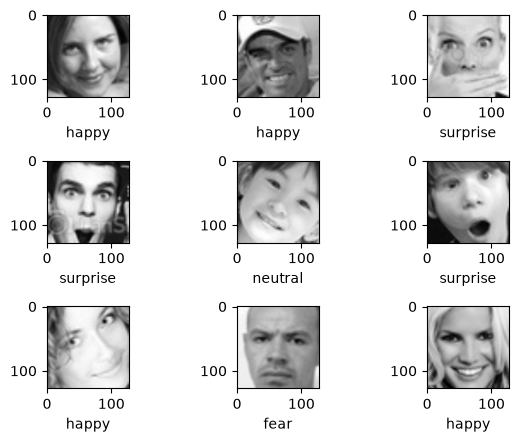

In [27]:
batch_imgs, batch_labels = next(iter(train_loader))
num_imgs = 9
plt.figure(figsize=(6, 7))
for idx in range(num_imgs):
    plt.subplot(num_imgs//2+1, 3, idx+1)
    np_img = ((batch_imgs[idx].numpy()+1)*127.5).astype("uint8")
    np_label = batch_labels[idx].item()
    plt.imshow(np.transpose(np_img, (1, 2, 0)), cmap="gray")
    plt.xlabel(idx2label[np_label])

plt.tight_layout()
plt.show()

## **4. Build MLP network**

In [28]:
### WRITE YOUR CODE HERE

class MLP(nn.Module):
    def __init__(self, input_dims, hidden_dims, output_dims):
        super().__init__()
        self.layer1 = nn.Linear(input_dims, hidden_dims*4)
        self.layer2 = nn.Linear(hidden_dims*4, hidden_dims*2)
        self.layer3 = nn.Linear(hidden_dims*2, hidden_dims)
        self.layer4 = nn.Linear(hidden_dims, output_dims)
        self.flatten = nn.Flatten()

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = F.relu(self.layer3(x))
        output = self.layer4(x)

        return output.squeeze(1)

In [52]:
### WRITE YOUR CODE HERE
# EX3_MODEL_SETUP
# Complete MLP above, then create model.to(device), CrossEntropyLoss, and SGD(lr=0.01).
# Use input_dims=img_height*img_width, hidden_dims=64, output_dims=len(classes).
input_dims = img_height*img_width
output_dims = len(classes)
hidden_dims = 64

model = MLP(input_dims, hidden_dims, output_dims)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

## **5. Training**

In [53]:
def compute_accuracy(y_hat: torch.Tensor, y_true: torch.Tensor,):

    ### WRITE YOUR CODE HERE
    _, y_pred = torch.max(y_hat, dim=1)
    correct = (y_true == y_pred).sum().item()

    return correct / len(y_true)

In [54]:
### WRITE YOUR CODE HERE
# EX3_TRAINING_INITIALIZATION
# Define epochs=40 and initialize train_losses, val_losses, train_accs, and val_accs.
epochs = 40
train_losses = []
val_losses = []
train_accs = []
val_accs = []

In [55]:
import time

In [56]:
# Write the training pipeline
for i in range(epochs):
    start_time = time.time()
    train_loss = 0.0
    train_trues = []
    train_preds = []
    model.train()
    for X_samples, y_samples in train_loader:
        # Load data into GPU
        X_samples = X_samples.to(device)
        y_samples = y_samples.to(device)

        # Clear out gradient
        optimizer.zero_grad()

        # Forward pass
        outputs = model(X_samples)

        # Calculate loss
        loss = criterion(outputs, y_samples)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # Record loss, true y and predictions
        train_loss += loss.item()
        train_trues.append(y_samples.detach().cpu())
        train_preds.append(outputs.cpu())

    # Average train losses
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # Calculate accuracy
    train_trues = torch.cat(train_trues)
    train_preds = torch.cat(train_preds)
    train_accs.append(compute_accuracy(train_preds, train_trues))

    # Evaluation on validation set
    val_loss = 0.0
    val_trues = []
    val_preds = []
    model.eval()
    with torch.no_grad():
        for X_samples, y_samples in val_loader:
            
            X_samples = X_samples.to(device)
            y_samples = y_samples.to(device)

            outputs = model(X_samples)
            loss = criterion(outputs, y_samples)

            val_loss += loss.item()
            val_trues.append(y_samples.detach().cpu())
            val_preds.append(outputs.cpu())

        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        val_trues = torch.cat(val_trues)
        val_preds = torch.cat(val_preds)
        val_accs.append(compute_accuracy(val_preds, val_trues))

    end_time = time.time()

    print(f"\nEpoch {i+1}:\tTraining loss: {train_loss}\tValidation Loss: {val_loss}\tTime: {round(end_time-start_time, 1)}s")


Epoch 1:	Training loss: 1.8957642647955153	Validation Loss: 1.8605253229970518	Time: 30.8s

Epoch 2:	Training loss: 1.836397397518158	Validation Loss: 1.813499232997065	Time: 28.9s

Epoch 3:	Training loss: 1.7992535604370965	Validation Loss: 1.7850157281626826	Time: 25.9s

Epoch 4:	Training loss: 1.7740683582093981	Validation Loss: 1.7649561270423557	Time: 29.2s

Epoch 5:	Training loss: 1.7532806277275086	Validation Loss: 1.7441597347674163	Time: 29.0s

Epoch 6:	Training loss: 1.7312267515394422	Validation Loss: 1.7217288691064585	Time: 28.8s

Epoch 7:	Training loss: 1.7072390145725673	Validation Loss: 1.6978339682454648	Time: 28.9s

Epoch 8:	Training loss: 1.683434800306956	Validation Loss: 1.6780612157738728	Time: 25.0s

Epoch 9:	Training loss: 1.6640112280845643	Validation Loss: 1.6659635720045671	Time: 28.1s

Epoch 10:	Training loss: 1.6478177454736498	Validation Loss: 1.6530623021333113	Time: 28.4s

Epoch 11:	Training loss: 1.6353183534410265	Validation Loss: 1.6465348575426184	T

### Hint

1. Initialize parameters: learning rate, epochs
2. Create: 
    * optimizer, loss function, 
    * buffer for losses and accuracies for trainset and valset for each epoch
3. Loop through epochs:
    * Set train loss to 0; Create buffers for labels and predictions; turn on **training** mode
    * Loop through batches:
        1. Load data (X) and labels (y) into gpu
        2. Clear out gradients
        3. Forward pass
        4. Calculate loss
        5. Backward pass (method on the loss)
        6. Update weights (method on the optimizer)
        7. Acummulate loss value (Extract value using ```.item()```)
        8. Detach outputs from the computational graph and load them into CPU ```detach().cpu()```; Append to the buffer
        9. Load labels into CPU; Append to buffer
    * Average the losses; Append to the loss buffer
    * Calculate Accuracies; Append to the accs buffer
    * Set val loss to 0; Create buffers for labels and predictions; turn on **evaluation** mode
    * Loop through the validation loader and do the same steps like for training, exclude the backward pass and update weights
    * Print the epoch and the losses for the training and validation sets

<details><summary>Click here for the training pipeline sample</summary>

```python
for epoch in range(epochs):
    train_loss = 0.0
    train_target = []
    train_predict = []
    model.train()
    for X_samples, y_samples in train_loader:
        X_samples = X_samples.to(device)
        y_samples = y_samples.to(device)
        optimizer.zero_grad()
        outputs = model(X_samples)
        loss = criterion(outputs, y_samples)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        train_predict.append(outputs.detach().cpu())
        train_target.append(y_samples.cpu())

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    train_predict = torch.cat(train_predict)
    train_target = torch.cat(train_target)
    train_acc = compute_accuracy(train_predict, train_target)
    train_accs.append(train_acc)

    val_loss = 0.0
    val_target = []
    val_predict = []
    model.eval()
    with torch.no_grad():
        for X_samples, y_samples in val_loader:
            X_samples = X_samples.to(device)
            y_samples = y_samples.to(device)
            outputs = model(X_samples)
            val_loss += criterion(outputs, y_samples).item()

            val_predict.append(outputs.cpu())
            val_target.append(y_samples.cpu())

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    val_predict = torch.cat(val_predict)
    val_target = torch.cat(val_target)
    val_acc = compute_accuracy(val_predict, val_target)
    val_accs.append(val_acc)

    print(f'\nEPOCH {epoch + 1}:\tTraining loss: {train_loss:.3f}\tValidation loss: {val_loss:.3f}')
```

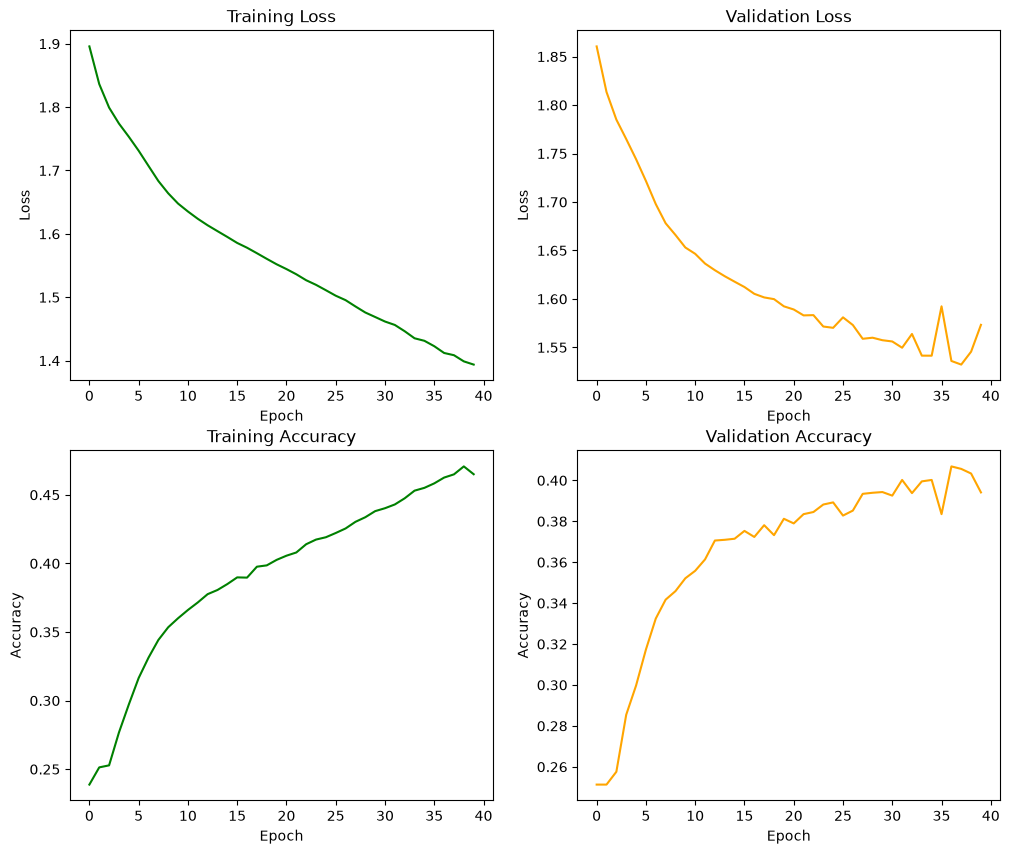

In [57]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax[0, 0].plot(train_losses, color='green')
ax[0, 0].set(xlabel='Epoch', ylabel='Loss')
ax[0, 0].set_title('Training Loss')

ax[0, 1].plot(val_losses, color='orange')
ax[0, 1].set(xlabel='Epoch', ylabel='Loss')
ax[0, 1].set_title('Validation Loss')

ax[1, 0].plot(train_accs, color='green')
ax[1, 0].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 0].set_title('Training Accuracy')

ax[1, 1].plot(val_accs, color='orange')
ax[1, 1].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 1].set_title('Validation Accuracy')

plt.show()

## **7. Evaluation**

In [58]:
val_target = []
val_predict = []
model.eval()
with torch.no_grad():
    for X_samples, y_samples in val_loader:
        X_samples = X_samples.to(device)
        y_samples = y_samples.to(device)
        outputs = model(X_samples)

        val_predict.append(outputs.cpu())
        val_target.append(y_samples.cpu())

    val_predict = torch.cat(val_predict)
    val_target = torch.cat(val_target)
    val_acc = compute_accuracy(val_predict, val_target)

    print('Evaluation on val set:')
    print(f'Accuracy: {val_acc}')

Evaluation on val set:
Accuracy: 0.3941135492859631


In [59]:
### WRITE YOUR CODE HERE
# EX3_TEST_EVALUATION
# Evaluate the trained model on test_loader with model.eval() and torch.no_grad().
# Compute and print test_acc separately from val_acc.
test_target = []
test_predict = []
model.eval()
with torch.no_grad():
    for X_samples, y_samples in test_loader:
        X_samples = X_samples.to(device)
        y_samples = y_samples.to(device)
        outputs = model(X_samples)

        test_predict.append(outputs.cpu())
        test_target.append(y_samples.cpu())

    test_predict = torch.cat(test_predict)
    test_target = torch.cat(test_target)
    test_acc = compute_accuracy(test_predict, test_target)

    print('Evaluation on val set:')
    print(f'Accuracy: {test_acc}')

Evaluation on val set:
Accuracy: 0.40540540540540543
